# Can We Predict Diabetes Progression? An End-to-End Walkthrough with EDA and Linear Regression

When a patient receives a clinical diagnosis of early-stage diabetes, doctors face a vital question: **How fast will this disease progress over the next 12 months?**

Is disease escalation driven primarily by physical attributes like body mass and blood pressure, or are blood serum biomarkers the real hidden culprits? 

In this first deep dive of our Machine Learning series, we explore the data like a detective, validate our hypotheses through statistical tests, fit an Ordinary Least Squares (OLS) Linear Regression model, evaluate its diagnostic residuals, and interpret what the results mean in clinical practice.

## 1. Inspecting the Patient Cohort

We begin by loading the benchmark Diabetes dataset from `scikit-learn`. The dataset tracks **442 diabetes patients**, recording 10 baseline biometric markers to predict quantitative disease progression measured one year later (ranging from 25 to 346).

* **Demographics & Biometrics:** Patient age, sex, Body Mass Index (`bmi`), and average blood pressure (`bp`).
* **Blood Serum Biomarkers:** Six laboratory assays: `s1` (total cholesterol), `s2` (LDL), `s3` (HDL), `s4` (total/HDL ratio), `s5` (serum triglycerides), and `s6` (blood glucose).

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Load the dataset
diabetes_data = load_diabetes(as_frame=True)
df = diabetes_data.frame

print(f"Dataset Loaded Successfully: {df.shape[0]} patients, {df.shape[1]} total columns\n")
df.head()

Dataset Loaded Successfully: 442 patients, 11 total columns



,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


## 2. Exploratory Data Analysis: Outlier Screening & Skewness

Before fitting an algorithm, we examine the distributional characteristics of our variables. Features in this benchmark have already been mean-centered and standardized ($\mu \approx 0, \sigma \approx 0.048$).

We analyze:
* **Skewness:** Values where $|\text{skew}| > 0.5$ indicate moderate asymmetry requiring attention.
* **Boxplots:** Identifying clinical outliers sitting beyond the $1.5 \times \text{IQR}$ outer fence.

--- Skewness Table ---


,Feature,Skewness
0,s3,0.799255
1,s4,0.735374
2,bmi,0.598148
3,target,0.440563
4,s2,0.436592
5,s1,0.378108
6,s5,0.291754
7,bp,0.290658
8,s6,0.207917
9,sex,0.127385


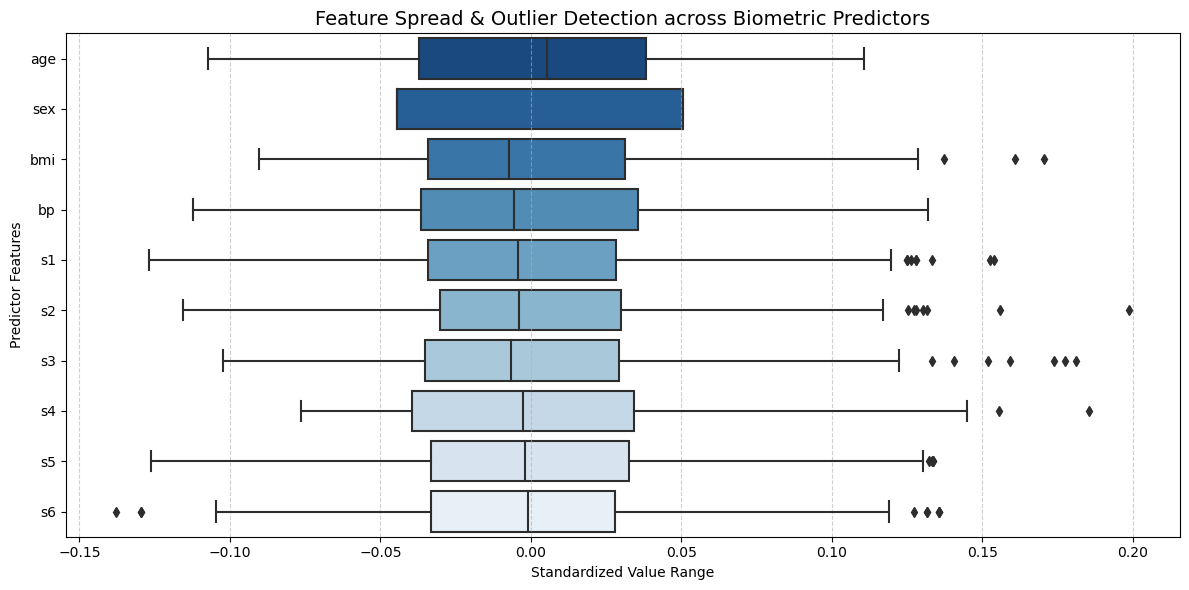

In [4]:
# 1. Compute Skewness
skew_df = pd.DataFrame({
    'Feature': df.columns,
    'Skewness': df.skew()
}).sort_values(by='Skewness', ascending=False).reset_index(drop=True)

print("--- Skewness Table ---")
display(skew_df)

# 2. Plot Horizontal Boxplots for Outlier Detection
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.drop(columns=['target']), orient='h', palette='Blues_r')
plt.title("Feature Spread & Outlier Detection across Biometric Predictors", fontsize=14)
plt.xlabel("Standardized Value Range")
plt.ylabel("Predictor Features")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Observations from EDA
* **Symmetry:** Most serum features remain approximately symmetric around zero.
* **Outliers:** Features such as `s2` (LDL) and `s3` (HDL) show isolated points beyond the whiskers ($> 1.5 \times \text{IQR}$). Because Ordinary Least Squares minimizes squared residuals, these high-leverage points exert strong gravitational pull on a linear plane.

## 3. Statistical Hypothesis Testing: Does Every Feature Matter?

A frequent modeling pitfall is throwing every column into a regression without validating its significance. We formulate a two-tailed null hypothesis test for each feature:
* **Null Hypothesis ($H_0$):** There is no linear correlation between the feature and disease progression ($r = 0$).
* **Alternative Hypothesis ($H_1$):** A statistically significant linear correlation exists ($r \neq 0$).

We compute both parametric (Pearson $r$) and non-parametric (Spearman $\rho$) coefficients along with $p$-values at a strict significance threshold ($\alpha = 0.01$).

In [5]:
stat_records = []
for col in df.columns.drop('target'):
    r_stat, p_val = stats.pearsonr(df[col], df['target'])
    rho_stat, rho_pval = stats.spearmanr(df[col], df['target'])
    
    stat_records.append({
        'Feature': col,
        'Pearson r': round(r_stat, 4),
        'p-value (Pearson)': f"{p_val:.2e}",
        'Spearman rho': round(rho_stat, 4),
        'Significant (alpha=0.01)': 'YES' if p_val < 0.01 else 'NO'
    })

hypothesis_df = pd.DataFrame(stat_records).sort_values(by='Pearson r', ascending=False)
display(hypothesis_df.reset_index(drop=True))

,Feature,Pearson r,p-value (Pearson),Spearman rho,Significant (alpha=0.01)
0,bmi,0.5865,3.47e-42,0.5614,YES
1,s5,0.5659,8.83e-39,0.5894,YES
2,bp,0.4415,1.65e-22,0.4162,YES
3,s4,0.4305,2.30e-21,0.4489,YES
4,s6,0.3825,7.58e-17,0.3508,YES
5,s1,0.2120,6.92e-06,0.2324,YES
6,age,0.1879,7.06e-05,0.1978,YES
7,s2,0.1741,2.36e-04,0.1958,YES
8,sex,0.0431,3.66e-01,0.0374,NO
9,s3,-0.3948,6.16e-18,-0.4100,YES


### Inferences from Hypothesis Testing
1. **The Primary Drivers:** Body Mass Index (`bmi`, $r = 0.5865, p = 3.47 \times 10^{-42}$) and Serum Triglycerides (`s5`, $r = 0.5659, p = 8.83 \times 10^{-39}$) show strong positive correlations that reject $H_0$ with overwhelming significance.
2. **The Protective Shield:** High-Density Lipoprotein (`s3`, $r = -0.3948, p = 6.16 \times 10^{-18}$) is negatively correlated—confirming the clinical role of "good" cholesterol in moderating deterioration.
3. **The Non-Factor:** Biological `sex` ($p = 0.366$) fails to achieve significance at $\alpha = 0.05$. Sex alone does not provide independent linear explanatory power for 1-year progression rate.

## 4. Modeling: Ordinary Least Squares (OLS) Linear Regression

Linear Regression models disease progression $\hat{y}$ as a weighted linear combination:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_p x_p$$

Rather than iteratively tuning hyperparameters, OLS computes the optimal parameter vector $\hat{\boldsymbol{\beta}}$ in closed form by minimizing the Residual Sum of Squares (RSS):

$$\hat{\boldsymbol{\beta}} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$

We partition our dataset into an **80% training set** and a **20% unseen test set** to measure real generalization performance.

In [6]:
# 1. Split Features and Target
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Fit the Model
reg = LinearRegression()
reg.fit(X_train, y_train)

# 3. Predict on Test Set
y_pred = reg.predict(X_test)

# 4. Quantitative Metrics
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"R² Score (Variance Explained) : {r2:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE)     : {mae:.4f}")

R² Score (Variance Explained) : 0.4526
Root Mean Squared Error (RMSE): 53.8534
Mean Absolute Error (MAE)     : 42.7941


## 5. Model Diagnostics & Residual Analysis

To verify regression assumptions (linearity and homoscedasticity), we construct two diagnostic plots:
1. **Actual vs. Predicted Plot:** Evaluates how tightly test predictions align along the 1:1 identity line ($y = x$).
2. **Residual Plot:** Checks whether residuals ($y - \hat{y}$) scatter symmetrically around zero with uniform variance across all prediction magnitudes.

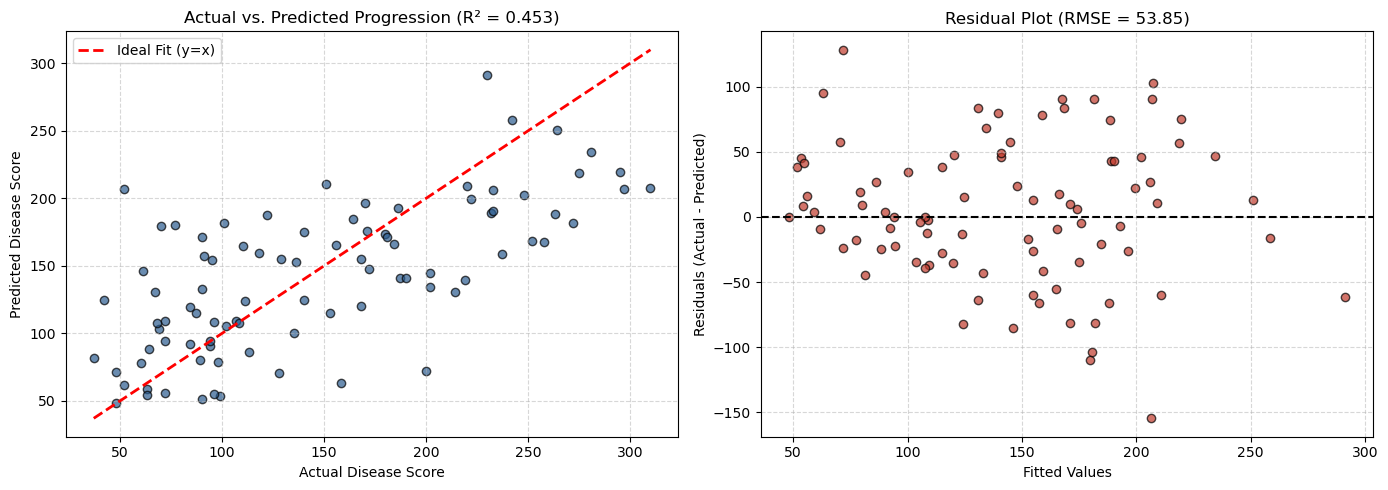

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted Scatter
axes[0].scatter(y_test, y_pred, color='#2b5c8f', edgecolor='k', alpha=0.7)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Fit (y=x)')
axes[0].set_title(f"Actual vs. Predicted Progression (R² = {r2:.3f})")
axes[0].set_xlabel("Actual Disease Score")
axes[0].set_ylabel("Predicted Disease Score")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Residuals vs Fitted
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, color='#c0392b', edgecolor='k', alpha=0.7)
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_title(f"Residual Plot (RMSE = {rmse:.2f})")
axes[1].set_xlabel("Fitted Values")
axes[1].set_ylabel("Residuals (Actual - Predicted)")
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 6. Real-World Findings & Clinical Summary

* **Performance Context:** The model yields an $R^2$ of **0.4526**, demonstrating that baseline non-invasive markers explain roughly **45.3%** of disease variance on unseen patients. In clinical modeling, this is a solid predictive baseline, reflecting that human metabolic systems are inherently complex.
* **Homoscedasticity Confirmed:** The residual plot shows errors distributed relatively evenly around zero through the central prediction band (100–200), confirming constant error variance.
* **Non-Linear Ceiling Effect:** In the Actual vs. Predicted plot, patients with extreme progression ($y > 250$) are systematically underpredicted. A planar linear hyperplane cannot bend to capture rapid acceleration in late-stage diabetes.
* **Why No Confusion Matrix or ROC Curve?** Confusion matrices and ROC curves require discrete classification boundaries (e.g., positive vs. negative). Because Linear Regression predicts a continuous real-valued quantity ($y \in \mathbb{R}$), residual diagnostics ($R^2$, RMSE, and MAE) serve as the direct mathematical evaluation standard.